In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, confusion_matrix, classification_report, accuracy_score

# Linear Regression Model

Mean Squared Error: 49830096.855908334
R^2 Score: 0.9024461774180498


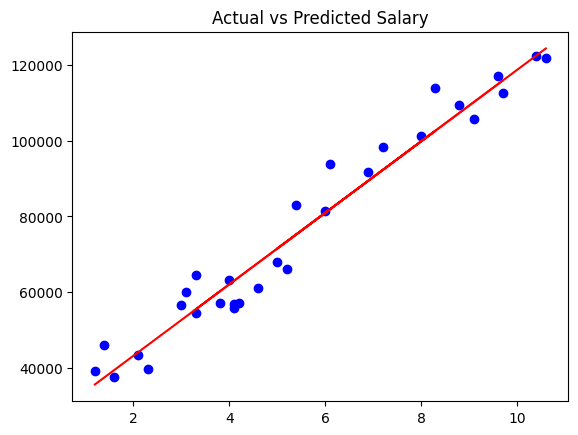

In [ ]:
# Build Linear Regression Model
df = pd.read_csv('Salary_dataset.csv')
x = df['YearsExperience'].values.reshape(-1, 1)
y = df['Salary'].values.reshape(-1, 1)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R^2 Score:", r2_score(y_test, y_pred))
plt.scatter(x, y, color='blue')
plt.plot(x, model.predict(x), color='red')
plt.title("Actual vs Predicted Salary")
plt.plot(x_test, y_pred, color='red', label='Predicted')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.legend()
plt.show()

# Logistic Regression Model

Confusion Matrix:
 [[70  1]
 [ 2 41]]
Classification Report:
               precision    recall  f1-score   support

           B       0.97      0.99      0.98        71
           M       0.98      0.95      0.96        43

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

Accuracy Score: 0.9736842105263158


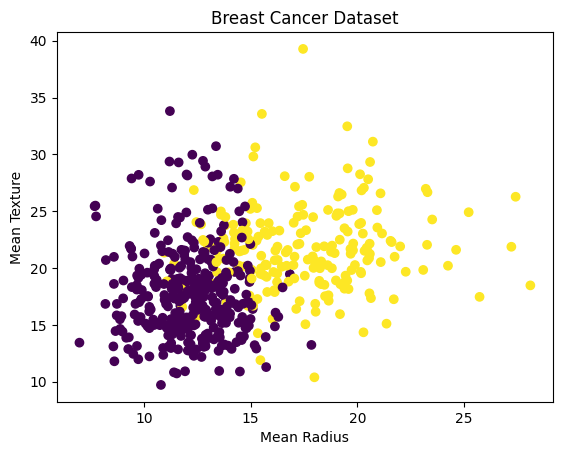

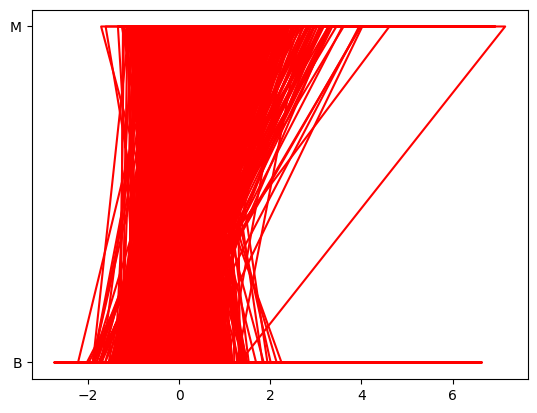

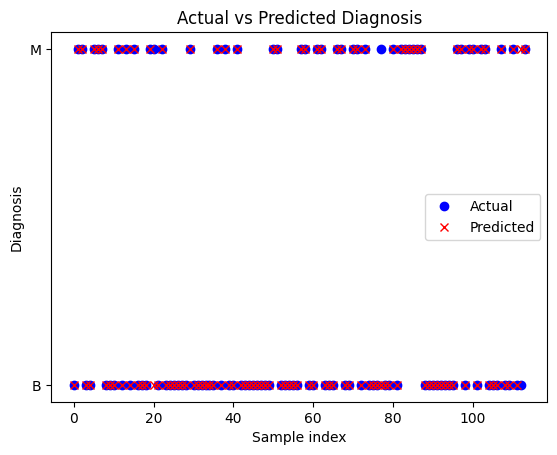

In [8]:
cancer_df = pd.read_csv('breast-cancer.csv')
xc = cancer_df.drop('diagnosis', axis=1)
yc = cancer_df['diagnosis'].values.reshape(-1, 1)
xc_train, xc_test, yc_train, yc_test = train_test_split(xc, yc, test_size=0.2, random_state=42)

scaler = StandardScaler()
xc_train = scaler.fit_transform(xc_train)
xc_test = scaler.transform(xc_test)
logistic_model = LogisticRegression()
logistic_model.fit(xc_train, yc_train.ravel())
yc_pred = logistic_model.predict(xc_test)
print("Confusion Matrix:\n", confusion_matrix(yc_test, yc_pred))
print("Classification Report:\n", classification_report(yc_test, yc_pred))
print("Accuracy Score:", accuracy_score(yc_test, yc_pred))
colors = cancer_df['diagnosis'].map({'B': 0, 'M': 1})
plt.scatter(xc['radius_mean'], xc['texture_mean'], c=colors, cmap='viridis')
plt.xlabel('Mean Radius')
plt.ylabel('Mean Texture')
plt.title('Breast Cancer Dataset')
plt.show()
plt.plot(xc_test, yc_pred, color='red', label='Predicted')
label_map = {'B': 0, 'M': 1}
yc_test_encoded = np.array([label_map[label] for label in yc_test.ravel()])
yc_pred_encoded = np.array([label_map[label] for label in yc_pred.ravel()])

plt.figure()
plt.plot(yc_test_encoded, 'bo', label='Actual')
plt.plot(yc_pred_encoded, 'rx', label='Predicted')
plt.yticks([0, 1], ['B', 'M'])
plt.xlabel('Sample index')
plt.ylabel('Diagnosis')
plt.title('Actual vs Predicted Diagnosis')
plt.legend()
plt.show()